<a href="https://colab.research.google.com/github/alt-gabby/qml-assignments/blob/main/1_Variational%20Quantum%20Eigensolver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 65.2 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
import numpy as np
from pennylane import numpy as pnp
from scipy.optimize import minimize
import matplotlib.pyplot as plt


The supplementary information says the FCI hamiltonian has dimension four meaning we are dealing with two qubits. so i,j={1,2}
The equation
\begin{equation}
H(R) = h_{II}(I\otimes I)
     + h_{IX}(I\otimes X)
     + h_{IZ}(I\otimes Z)
     + h_{XI}(X\otimes I)
     + h_{ZI}(Z\otimes I)
     + h_{XX}(X\otimes X)
     + h_{XZ}(X\otimes Z)
     + h_{ZX}(Z\otimes X)
     + h_{ZZ}(Z\otimes Z)
\end{equation}

Below the coefficients are chosen for internuclear separation, R=0.9 Å, which is what it is for He-H.


In [ ]:
coeffs = [-3.8505, -0.2288, -1.0466, -0.2288, 0.2613, 0.2288, -1.0466, 0.2288, 0.2356]# Theres are the coefficients from the supplementary information Table 2, where the interatomic distance is 0.9Å.


observables = [
    qml.Identity(0) @ qml.Identity(1),
    qml.Identity(0) @ qml.PauliX(1),
    qml.Identity(0) @ qml.PauliZ(1),
    qml.PauliX(0) @ qml.Identity(1),
    qml.PauliX(0) @ qml.PauliX(1),
    qml.PauliX(0) @ qml.PauliZ(1),
    qml.PauliZ(0) @ qml.Identity(1),
    qml.PauliZ(0) @ qml.PauliX(1),
    qml.PauliZ(0) @ qml.PauliZ(1)
]

H = qml.Hamiltonian(coeffs, observables)#Hamiltonian function pairs up the coefficients and the observables

In [ ]:
# -----------------------------
# Quantum device
# -----------------------------
dev = qml.device("default.qubit", wires = 2) #creates simulator with 2 qubits (pennyLanes built-in statevector simulator
@qml.qnode(dev) #makes the Python function into a quantum node

# -----------------------------
# Variational ansatz
# -----------------------------
def circuit(params): #takes a list of parameters of 4 angles
  qml.RY(params[0], wires = 0) #applies a rotation around Y-axis by angle theta_0 to qubit 0
  qml.RY(params[1], wires = 1) #applies a rotation around Y-axis by angle theta_1 to qubit 1
  qml.CNOT(wires = [0,1]) #applies a CNOT gate with control qubit 0 and target qubit 1
  qml.RY(params[2], wires = 0) #applies a rotation around Y-axis by angle theta_2 to qubit 0
  qml.RY(params[3], wires = 1) #applies a rotation around Y-axis by angle theta_3 to qubit 1
  return qml.expval(H) #returns the expectation value of the Hamiltonian H


In [ ]:
params = np.zeros(4)
print(qml.draw(circuit)(params))

0: ──RY(0.00)─╭●──RY(0.00)─┤ ╭<𝓗>
1: ──RY(0.00)─╰X──RY(0.00)─┤ ╰<𝓗>


The code below is meant to write out the hamiltonian to the calculate the exact ground state energy obtained from classical diagonalisation.

In [ ]:
I = np.eye(2)
X = np.array([[0,1],[1,0]])
Z = np.array([[1,0],[0,-1]])

H_matrix = (coeffs[0]*np.kron(I,I) + coeffs[1]*np.kron(I,X) + coeffs[2]*np.kron(I,Z)
          + coeffs[3]*np.kron(X,I) + coeffs[4]*np.kron(X,X) + coeffs[5]*np.kron(X,Z)
          + coeffs[6]*np.kron(Z,I) + coeffs[7]*np.kron(Z,X) + coeffs[8]*np.kron(Z,Z))

eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
E_exact = eigenvalues[0]
psi_exact = eigenvectors[:, 0]

In [ ]:
print(f"E_exact =" + str(E_exact))
print(f"psi_exact =" +str(psi_exact))

E_exact =-5.725241528153364
psi_exact =[-0.99760736  0.01575801  0.01575801  0.06544399]


In [ ]:
@qml.qnode(dev)
def statevector(params):
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0,1])
    qml.RY(params[2], wires=0)
    qml.RY(params[3], wires=1)
    return qml.state()

energy_history = []
delta_history = []
fidelity_history = []

def cost(params):
    E_vqe = circuit(params)
    psi_vqe = statevector(params)

    energy_history.append(E_vqe)
    delta_history.append(abs(E_vqe - E_exact))
    fidelity_history.append(abs(np.dot(np.conj(psi_exact), psi_vqe))**2)

    return E_vqe

params0 = np.random.uniform(0, 2*np.pi, 4)
result = minimize(cost, params0, method='Nelder-Mead')

# Plots of variational energy, E, E-E_exact, and fidelity as a function of iteration respectively.

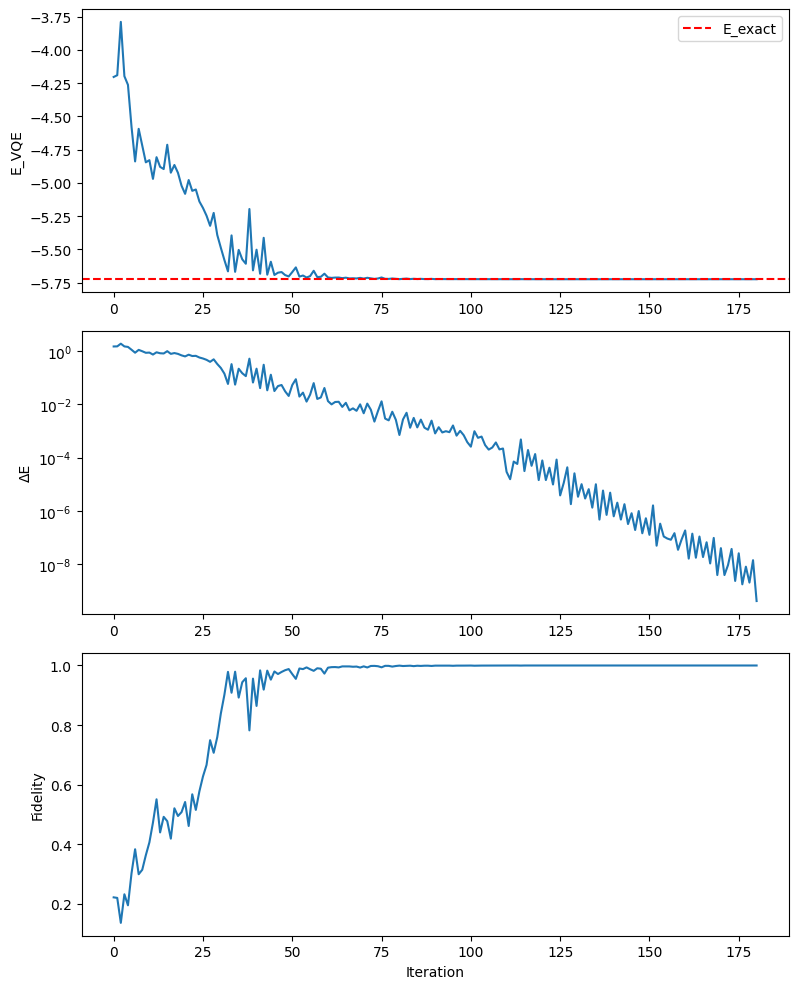

E_exact = -5.725242
E_VQE   = -5.725242


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

axes[0].plot(energy_history)
axes[0].axhline(E_exact, color='r', linestyle='--', label='E_exact')
axes[0].set_ylabel('E_VQE')
axes[0].legend()

axes[1].plot(delta_history)
axes[1].set_ylabel('ΔE')
axes[1].set_yscale('log')

axes[2].plot(fidelity_history)
axes[2].set_ylabel('Fidelity')
axes[2].set_xlabel('Iteration')

plt.tight_layout()
plt.show()

print(f"E_exact = {E_exact:.6f}")
print(f"E_VQE   = {result.fun:.6f}")